<a href="https://colab.research.google.com/github/daedara007/Machine-Learning-B-Group-11/blob/main/Rev_2_Machine_Learning_Group_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Data Prepocessing and geocoding**

In [ ]:
import pandas as pd

print("Memuat file data mentah...")
# Membaca file CSV sesuai nama yang kamu berikan
df_raw = pd.read_csv('rumah123 (2) (1).csv')

print("\n" + "="*50)
print("DAFTAR NAMA KOLOM DI DATASET:")
print("="*50)
# Ini akan menampilkan daftar nama kolom yang benar-benar ada di file
print(df_raw.columns.tolist())

print("\n" + "="*50)
print("JUMLAH MISSING VALUE PER KOLOM:")
print("="*50)
# Ini akan langsung mengecek missing value untuk semua kolom
missing_data = df_raw.isnull().sum()
print(missing_data[missing_data > 0]) # Hanya menampilkan kolom yang ada kosongnya

Memuat file data mentah...

DAFTAR NAMA KOLOM DI DATASET:
['Harga', 'Link', 'Judul', 'Lokasi', 'Bedroom', 'Bathroom', 'Carport', 'LT', 'LB', 'Seller', 'Phone']

JUMLAH MISSING VALUE PER KOLOM:
Harga         1
Link          1
Judul         2
Lokasi        1
Bedroom      13
Bathroom     18
Carport     453
LT            1
LB            1
Seller        1
Phone         1
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import time
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

# Aktifkan progress bar untuk pandas
tqdm.pandas(desc="Geocoding Progress")

print("Memuat dataset...")
df = pd.read_csv('rumah123 (2) (1).csv')

# --- 1. FASE PARSING DATA ---
def parse_harga(x):
    x = str(x).replace('Rp ', '').strip()
    multiplier = 1
    if 'Juta' in x:
        multiplier = 1e6
        x = x.replace(' Juta', '')
    elif 'Miliar' in x:
        multiplier = 1e9
        x = x.replace(' Miliar', '')
    elif 'Ribu' in x:
        multiplier = 1e3
        x = x.replace(' Ribu', '')
    x = x.replace(',', '.')
    try:
        return float(x) * multiplier
    except:
        return np.nan

def parse_area(x):
    x = str(x).replace(' m²', '').strip()
    try:
        return float(x)
    except:
        return np.nan

def parse_room(x):
    x = str(x).strip()
    if '+' in x:
        return sum([float(p.strip()) for p in x.split('+') if p.strip().isnumeric()])
    try:
        return float(x)
    except:
        return 0.0

print("Membersihkan teks menjadi numerik...")
df['Harga_Num'] = df['Harga'].apply(parse_harga)
df['LT_Num'] = df['LT'].apply(parse_area)
df['LB_Num'] = df['LB'].apply(parse_area)
df['Bedroom_Num'] = df['Bedroom'].fillna('0').apply(parse_room)
df['Bathroom_Num'] = df['Bathroom'].fillna('0').apply(parse_room)

# --- 2. FASE FILTERING ---
df = df.dropna(subset=['Harga_Num', 'LT_Num', 'LB_Num'])
df = df[df['LT_Num'] > 0] # Hapus luas tanah 0
batas_harga_logis = 50000000
df = df[df['Harga_Num'] >= batas_harga_logis] # Buang data sewa
df['Harga_per_m2'] = df['Harga_Num'] / df['LT_Num']

# --- 3. FASE KONVERSI LOKASI KE KARDINAL (MAPPING INTEGER) ---
print("Memulai standarisasi wilayah dan konversi ke integer...")

# Kamus 1: Mengelompokkan kelurahan/perumahan ke 6 Kecamatan Utama
kamus_kecamatan = {
    'Balikpapan Utara, Balikpapan': 'Utara',
    'Batu Ampar, Balikpapan': 'Utara',
    'Gn. Samarinda, Balikpapan': 'Utara',
    'Karang Joang, Balikpapan': 'Utara',
    'Muara Rapak, Balikpapan': 'Utara',

    'Balikpapan Selatan, Balikpapan': 'Selatan',
    'Sepinggan, Balikpapan': 'Selatan',
    'Gunung Bahagia, Balikpapan': 'Selatan',
    'Balikpapan Baru, Balikpapan': 'Selatan', # Secara administratif dominan di Selatan

    'Balikpapan Timur, Balikpapan': 'Timur',
    'Batakan, Balikpapan': 'Timur',
    'Manggar Baru, Balikpapan': 'Timur',
    'Teritip, Balikpapan': 'Timur',
    'Lamaru, Balikpapan': 'Timur',
    'Manggar, Balikpapan': 'Timur',

    'Balikpapan Tengah, Balikpapan': 'Tengah',
    'Sumber Rejo, Balikpapan': 'Tengah',
    'Gn. Sari Ilir, Balikpapan': 'Tengah',
    'Karang Jati, Balikpapan': 'Tengah',

    'Balikpapan Kota, Balikpapan': 'Kota',
    'Damai, Balikpapan': 'Kota',
    'Prapatan, Balikpapan': 'Kota',
    'Klandasan Ilir, Balikpapan': 'Kota',
    'Telaga Sari, Balikpapan': 'Kota',
    'Klandasan Ulu, Balikpapan': 'Kota',

    'Balikpapan Barat, Balikpapan': 'Barat',
    'Kariangau, Balikpapan': 'Barat'
}

# Kamus 2: Mengubah nama Kecamatan menjadi Integer (Saran Dosen)
kamus_kardinal = {
    'Utara': 0,
    'Barat': 1,
    'Tengah': 2,
    'Selatan': 3,
    'Kota': 4,
    'Timur': 5
}

# Eksekusi Pemetaan (Mapping)
# Tahap 1: Ubah 'Gn Samarinda' dll menjadi 'Utara', dst.
df['Kecamatan'] = df['Lokasi'].map(kamus_kecamatan)

# Buang baris yang lokasinya kosong/tidak dikenali (jika ada)
df = df.dropna(subset=['Kecamatan'])

# Tahap 2: Ubah 'Utara' dll menjadi 0, 1, 2, 3, 4, 5
df['Lokasi_Num'] = df['Kecamatan'].map(kamus_kardinal)

print(f"Data berhasil dipetakan! Distribusi Kecamatan:\n{df['Kecamatan'].value_counts()}")


# --- 4. FASE NORMALISASI ---
print("\nMelakukan normalisasi rentang data...")
# Ganti Latitude & Longitude menjadi Lokasi_Num
numeric_features = ['Lokasi_Num', 'Harga_Num', 'LT_Num', 'LB_Num', 'Bedroom_Num', 'Bathroom_Num', 'Harga_per_m2']
df_clustering = df[numeric_features].copy()

scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_clustering), columns=df_clustering.columns)

# Simpan hasil
df_normalized.to_csv('dataset_spasial_ready_kardinal.csv', index=False)
df.to_csv('dataset_spasial_referensi_kardinal.csv', index=False)
print("Selesai! Data siap untuk proses eksperimen Clustering.")

# Simpan hasil
df_normalized.to_csv('dataset_spasial_ready.csv', index=False)
df.to_csv('dataset_spasial_referensi.csv', index=False)
print("Selesai! Data siap untuk K-Means dan DBSCAN spasial.")

Memuat dataset...
Membersihkan teks menjadi numerik...
Memulai standarisasi wilayah dan konversi ke integer...
Data berhasil dipetakan! Distribusi Kecamatan:
Kecamatan
Selatan    686
Utara      291
Kota        92
Tengah      86
Timur       63
Barat        8
Name: count, dtype: int64

Melakukan normalisasi rentang data...
Selesai! Data siap untuk proses eksperimen Clustering.
Selesai! Data siap untuk K-Means dan DBSCAN spasial.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Membuat visualisasi distribusi data (tanpa outliers ekstrem)...")

# Kita buat grid 3x2 untuk menampung 5 grafik fitur
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

judul_fitur = {
    'Harga_Num': 'Distribusi Harga Properti (98% Data Mayoritas)',
    'LB_Num': 'Distribusi Luas Bangunan (98% Data Mayoritas)',
    'LT_Num': 'Distribusi Luas Tanah (98% Data Mayoritas)',
    'Bedroom_Num': 'Distribusi Jumlah Kamar Tidur (98% Data Mayoritas)',
    'Bathroom_Num': 'Distribusi Jumlah Kamar Mandi (98% Data Mayoritas)'
}

for i, fitur in enumerate(fitur_numerik):
    # TRIK: Mencari batas persentil ke-98 untuk memotong 'ekor' panjang di kanan
    batas_atas = df_raw[fitur].quantile(0.98)

    # Filter data HANYA UNTUK DIGAMBAR, data aslinya tetap aman
    data_plot = df_raw[df_raw[fitur] <= batas_atas][fitur]

    # Plot histogram dengan data yang sudah di-zoom
    sns.histplot(data_plot, kde=True, ax=axes[i], color='royalblue', bins=30)

    axes[i].set_title(judul_fitur[fitur], fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')

# Menghapus plot ke-6 yang kosong
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**2. Knee locator function to help finding the epsilon value**

In [ ]:
!pip install kneed

**3. Elbow method to find the k value**

Loading data...
Executing pure Inertia (Elbow Method) calculation...


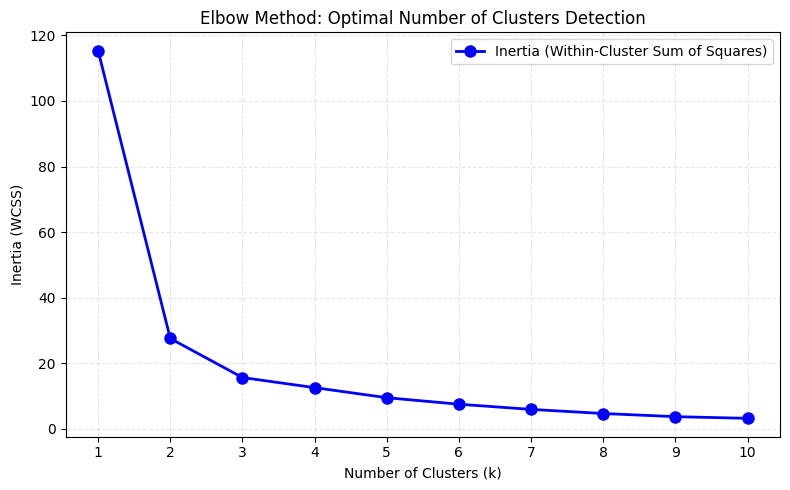

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("Loading data...")
# IMPORTANT: Load your data into variable X here!
# Adjust the filename to match your actual dataset
X = pd.read_csv('dataset_spasial_ready.csv')

print("Executing pure Inertia (Elbow Method) calculation...")

inertia = []
K_range = range(1, 11) # Safe to start from 1 since Silhouette evaluation is removed

# 1. Loop to calculate Inertia for each value of k
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# 2. Single Graph Visualization (Inertia Only)
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', label='Inertia (Within-Cluster Sum of Squares)', linewidth=2, markersize=8)

plt.title('Elbow Method: Optimal Number of Clusters Detection')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

**4. Silhouette Score to find optimal k value**

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Loading data...")
# Make sure this CSV file is uploaded to your Colab session
X = pd.read_csv('dataset_spasial_ready.csv')

print("Calculating evaluation metrics for each value of k...")

# Prepare an empty list to store the results
evaluation_results = []
K_range = range(2, 11) # Start from k=2 because Silhouette requires at least 2 clusters

for k in K_range:
    # 1. Initialize and run K-Means algorithm
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)

    # 2. Extract Inertia (WCSS) and Silhouette Score values
    inertia_val = kmeans.inertia_
    sil_val = silhouette_score(X, kmeans.labels_)

    # 3. Save the results into a dictionary, then append to the list
    evaluation_results.append({
        'Number of Clusters (k)': k,
        'Inertia Value (WCSS)': round(inertia_val, 2), # Rounded to 2 decimal places
        'Silhouette Score': round(sil_val, 4) # Rounded to 4 decimal places
    })

# Convert the list of dictionaries into a Pandas DataFrame
df_evaluation = pd.DataFrame(evaluation_results)

print("\n" + "="*50)
print("K-MEANS METRICS COMPARISON TABLE")
print("="*50)
# Display the table without the default Pandas index for a cleaner look
print(df_evaluation.to_string(index=False))

Loading data...
Calculating evaluation metrics for each value of k...

K-MEANS METRICS COMPARISON TABLE
 Number of Clusters (k)  Inertia Value (WCSS)  Silhouette Score
                      2                 27.51            0.7813
                      3                 15.59            0.7275
                      4                 12.51            0.7181
                      5                  9.43            0.7215
                      6                  7.44            0.7242
                      7                  5.86            0.7496
                      8                  4.61            0.7051
                      9                  3.65            0.7049
                     10                  3.13            0.6732


**5. Finding the optimal epsilon Value**

Loading data...
Calculating nearest neighbors distances...

AUTOMATIC DBSCAN CALCULATION RESULTS
-> Optimal Mathematical Epsilon (eps) : 0.0351
-> MinPts used                        : 14


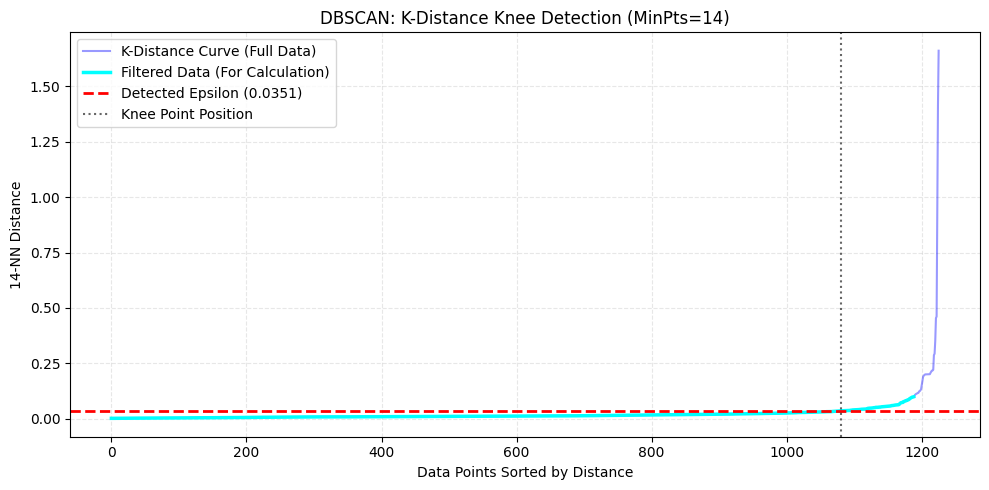

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

print("Loading data...")
# Make sure this CSV file is uploaded to your Colab session
X = pd.read_csv('dataset_spasial_ready.csv')

# ==========================================
# AUTOMATIC DBSCAN EPSILON CALCULATION
# ==========================================
min_pts = 14 # Rule of thumb: 2 * dimensions (7 features)

print("Calculating nearest neighbors distances...")
# Calculate distances to nearest neighbors
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort the distances to the k-th nearest neighbor
distances = np.sort(distances[:, -1], axis=0)

# Trimming Logic: Cut the top 3% extreme data so the algorithm isn't distorted
percentile_threshold = np.percentile(distances, 97)
distances_filtered = distances[distances <= percentile_threshold]

# Mathematical calculation of the DBSCAN knee point
kn_dbscan = KneeLocator(range(len(distances_filtered)), distances_filtered, curve='convex', direction='increasing')
optimal_eps = distances_filtered[kn_dbscan.knee]

print("\n" + "=" * 50)
print("AUTOMATIC DBSCAN CALCULATION RESULTS")
print("=" * 50)
print(f"-> Optimal Mathematical Epsilon (eps) : {optimal_eps:.4f}")
print(f"-> MinPts used                        : {min_pts}")
print("=" * 50)

# Plot the DBSCAN K-Distance Graph
plt.figure(figsize=(10, 5))

# Plot the full data with lower opacity
plt.plot(distances, label='K-Distance Curve (Full Data)', color='blue', alpha=0.4)
# Plot the filtered data used for calculation
plt.plot(range(len(distances_filtered)), distances_filtered, label='Filtered Data (For Calculation)', color='cyan', linewidth=2.5)

# Draw horizontal line for the detected Epsilon
plt.axhline(y=optimal_eps, color='red', linestyle='--', linewidth=2, label=f'Detected Epsilon ({optimal_eps:.4f})')

# Draw vertical line for the knee point position
if kn_dbscan.knee is not None:
    plt.axvline(x=kn_dbscan.knee, color='black', linestyle=':', linewidth=1.5, alpha=0.6, label='Knee Point Position')

plt.title(f'DBSCAN: K-Distance Knee Detection (MinPts={min_pts})')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{min_pts}-NN Distance')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**6. Train the Algorithm**

In [ ]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
import pandas as pd

# --- INPUT PARAMETERS FROM PREVIOUS GRAPHS ---
k_optimal = 4         # Set to 4 based on the Local Maximum strategy
eps_optimal = 0.0351  # From DBSCAN K-Distance graph
minpts_optimal = 2 * X.shape[1]

print(f"Running training with k={k_optimal} and eps={eps_optimal}...\n")

# ==========================================
# 1. K-MEANS TRAINING
# ==========================================
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

kmeans_sil = silhouette_score(X, kmeans_labels)
kmeans_dbi = davies_bouldin_score(X, kmeans_labels)

# ==========================================
# 2. DBSCAN TRAINING
# ==========================================
dbscan = DBSCAN(eps=eps_optimal, min_samples=minpts_optimal)
dbscan_labels = dbscan.fit_predict(X)

# Filter noise (label -1) for DBSCAN metric calculation
# Because Silhouette and DBI cannot evaluate noise as a valid cluster
valid_mask = dbscan_labels != -1
if len(set(dbscan_labels[valid_mask])) > 1:
    dbscan_sil = silhouette_score(X[valid_mask], dbscan_labels[valid_mask])
    dbscan_dbi = davies_bouldin_score(X[valid_mask], dbscan_labels[valid_mask])
else:
    dbscan_sil = 0
    dbscan_dbi = 0

# =====================
# 3. RESULTS COMPARISON
# =====================
print("-" * 50)
print("CLUSTERING METRICS EVALUATION RESULTS")
print("-" * 50)

print(f"K-MEANS (k={k_optimal})")
print(f"- Silhouette Score     : {kmeans_sil:.4f}")
print(f"- Davies-Bouldin Index : {kmeans_dbi:.4f} (Lower is better)")

print("\n" + "-" * 50)

print(f"DBSCAN (eps={eps_optimal}, minPts={minpts_optimal})")
print(f"- Silhouette Score     : {dbscan_sil:.4f} (Calculated without noise)")
print(f"- Davies-Bouldin Index : {dbscan_dbi:.4f} (Lower is better)")

print("-" * 50)

# Save predicted labels to the original dataset for manual profiling
df_original = pd.read_csv('dataset_spasial_referensi.csv')
df_original['KMeans_Cluster'] = kmeans_labels
df_original['DBSCAN_Cluster'] = dbscan_labels
df_original.to_csv('final_segmentation_results.csv', index=False)

Running training with k=4 and eps=0.0351...

--------------------------------------------------
CLUSTERING METRICS EVALUATION RESULTS
--------------------------------------------------
K-MEANS (k=4)
- Silhouette Score     : 0.7181
- Davies-Bouldin Index : 0.4920 (Lower is better)

--------------------------------------------------
DBSCAN (eps=0.0351, minPts=14)
- Silhouette Score     : 0.8081 (Calculated without noise)
- Davies-Bouldin Index : 0.2855 (Lower is better)
--------------------------------------------------


In [ ]:
# import pandas as pd

print("Reloading segmentation results data...")
# Reload the CSV file here to prevent NameError
df_profiling = pd.read_csv('final_segmentation_results.csv')

print("\n" + "="*85)
print("COMPLETE K-MEANS CLUSTER PROFILE (Price, Area, and Rooms)")
print("="*85)

# Helper function to find Mode (most frequent value) for Rooms
# Kept here in case you want to switch back from median to mode later
def get_mode(x):
    return x.mode()[0] if not x.mode().empty else None

# Calculate feature aggregations
complete_profile = df_profiling.groupby('KMeans_Cluster').agg(
    Property_Count=('KMeans_Cluster', 'count'),
    Median_Price=('Harga_Num', 'median'),
    Median_Building_Area=('LB_Num', 'median'), # Adjust column name if different
    Median_Land_Area=('LT_Num', 'median'),     # Adjust column name if different
    Modus_Bedrooms=('Bedroom_Num', get_mode), # Adjust column name if different
    Modus_Bathrooms=('Bathroom_Num', get_mode),# Adjust column name if different
    Modus_Lokasi=('Kecamatan', get_mode)
).reset_index()

# Format price for readability
complete_profile['Median_Price (Rp)'] = complete_profile['Median_Price'].apply(lambda x: f"Rp {x:,.0f}")

# Display the formatted table
display_columns = [
    'KMeans_Cluster', 'Property_Count', 'Median_Price (Rp)',
    'Median_Building_Area', 'Median_Land_Area', 'Modus_Bedrooms', 'Modus_Bathrooms', 'Modus_Lokasi'
]
print(complete_profile[display_columns].to_string(index=False))

Reloading segmentation results data...

COMPLETE K-MEANS CLUSTER PROFILE (Price, Area, and Rooms)
 KMeans_Cluster  Property_Count Median_Price (Rp)  Median_Building_Area  Median_Land_Area  Modus_Bedrooms  Modus_Bathrooms Modus_Lokasi
              0              94  Rp 2,355,000,000                 160.0             199.0             3.0              3.0       Tengah
              1             686  Rp 1,825,000,000                 144.0             162.0             3.0              2.0      Selatan
              2             291  Rp 1,300,000,000                 103.0             150.0             3.0              2.0        Utara
              3             155  Rp 1,600,000,000                 148.0             182.0             3.0              2.0         Kota


In [ ]:
# @title
import folium
import pandas as pd

print("Memuat data hasil segmentasi...")
# Pastikan menggunakan dataframe yang memiliki kolom Latitude dan Longitude
df_map = pd.read_csv('final_segmentation_results.csv')

# 1. Menentukan Titik Tengah Peta (Berdasarkan rata-rata koordinat Balikpapan)
center_lat = df_map['Latitude'].mean()
center_lon = df_map['Longitude'].mean()

# Membuat objek peta dasar (Zoom start 12 biasanya pas untuk ukuran kota)
peta_balikpapan = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron')

# 2. Membuat Kamus Warna untuk Tiap Klaster
# Sesuaikan warnanya agar kontras
warna_klaster = {
    0: 'red',       # Klaster 0: Merah
    1: 'blue',      # Klaster 1: Biru
    2: 'green',     # Klaster 2: Hijau (Kawasan Sultan)
    3: 'purple'     # Klaster 3: Ungu
}

print("Sedang merender titik properti ke dalam peta...")

# 3. Looping untuk memasukkan setiap rumah ke dalam peta
for index, row in df_map.iterrows():
    klaster = row['KMeans_Cluster']

    # Format harga agar rapi saat di-klik
    harga_format = f"Rp {row['Harga_Num']:,.0f}"

    # Isi teks yang akan muncul saat titik di-klik (Popup)
    info_popup = f"""
    <b>Info Properti</b><br>
    Klaster: {klaster}<br>
    Harga: {harga_format}
    """

    # Menambahkan titik (CircleMarker) ke peta
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5, # Ukuran titik
        color=warna_klaster.get(klaster, 'gray'), # Garis pinggir
        fill=True,
        fill_color=warna_klaster.get(klaster, 'gray'), # Warna isi
        fill_opacity=0.7,
        popup=folium.Popup(info_popup, max_width=250),
        tooltip=f"Klaster {klaster}" # Teks saat kursor diarahkan ke titik
    ).add_to(peta_balikpapan)

# 4. Menyimpan peta ke file HTML (Bisa dibuka di Google Chrome tanpa perlu Colab)
peta_balikpapan.save('Peta_Klaster_KMeans_Balikpapan.html')
print("Peta berhasil dibuat dan disimpan sebagai 'Peta_Klaster_KMeans_Balikpapan.html'")

# 5. Menampilkan peta langsung di dalam Google Colab
peta_balikpapan

In [ ]:
# import pandas as pd

print("Memuat ulang data hasil segmentasi...")
# Panggil kembali file CSV-nya di sini agar tidak terjadi NameError
df_profiling = pd.read_csv('final_segmentation_results.csv')

print("\n" + "="*80)
print("PROFIL LENGKAP KLASTER DBSCAN (Harga, Luas, dan Ruangan)")
print("="*80)

# Fungsi bantuan untuk mencari Modus (Nilai terbanyak) untuk Kamar
def get_mode(x):
    return x.mode()[0] if not x.mode().empty else None

# Menghitung agregasi fitur
profil_lengkap = df_profiling.groupby('DBSCAN_Cluster').agg(
    Jumlah_Properti=('DBSCAN_Cluster', 'count'),
    Median_Harga=('Harga_Num', 'median'),
    Median_Luas_Bangunan=('LB_Num', 'median'), # Sesuaikan nama kolom jika berbeda
    Median_Luas_Tanah=('LT_Num', 'median'),       # Sesuaikan nama kolom jika berbeda
    Modus_Kamar=('Bedroom_Num', get_mode),         # Sesuaikan nama kolom jika berbeda
    Modus_Kamar_Mandi=('Bathroom_Num', get_mode), # Sesuaikan nama kolom jika berbeda
    Modus_Lokasi=('Kecamatan', get_mode)
).reset_index()

# Format harga agar rapi
profil_lengkap['Median_Harga (Rp)'] = profil_lengkap['Median_Harga'].apply(lambda x: f"Rp {x:,.0f}")

# Tampilkan tabel yang rapi
kolom_tampil = ['DBSCAN_Cluster', 'Jumlah_Properti', 'Median_Harga (Rp)',
                'Median_Luas_Bangunan', 'Median_Luas_Tanah', 'Modus_Kamar', 'Modus_Kamar_Mandi', 'Modus_Lokasi']
print(profil_lengkap[kolom_tampil].to_string(index=False))

Memuat ulang data hasil segmentasi...

PROFIL LENGKAP KLASTER DBSCAN (Harga, Luas, dan Ruangan)
 DBSCAN_Cluster  Jumlah_Properti Median_Harga (Rp)  Median_Luas_Bangunan  Median_Luas_Tanah  Modus_Kamar  Modus_Kamar_Mandi Modus_Lokasi
             -1               96  Rp 4,500,000,000                 454.0              473.5          3.0                2.0      Selatan
              0              270  Rp 1,250,000,000                 100.0              147.5          3.0                2.0        Utara
              1              657  Rp 1,800,000,000                 140.0              160.0          3.0                2.0      Selatan
              2               59    Rp 950,000,000                  90.0              135.0          2.0                1.0        Timur
              3               74  Rp 2,175,000,000                 158.5              188.5          3.0                3.0       Tengah
              4               70  Rp 1,825,000,000                 150.5          

In [ ]:
# @title
import folium

# Membuat peta dasar
peta_dbscan = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron')

# Fungsi warna untuk DBSCAN (menggunakan hitam untuk noise)
def get_color(cluster_label):
    if cluster_label == -1: return 'black'  # Warna hitam untuk outlier/noise
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    return colors[cluster_label % len(colors)]

for index, row in df_map.iterrows():
    cluster = row['DBSCAN_Cluster']

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=4,
        color=get_color(cluster),
        fill=True,
        fill_color=get_color(cluster),
        fill_opacity=0.7,
        popup=f"DBSCAN Cluster: {cluster}<br>Harga: Rp {row['Harga_Num']:,.0f}",
        tooltip=f"Cluster: {cluster}"
    ).add_to(peta_dbscan)

peta_dbscan.save('Peta_DBSCAN_Balikpapan.html')
peta_dbscan